# GPT-4o

## 1.환경준비

### (1) 라이브러리 설치

In [1]:
!pip install langchain langchain_core langchain-openai -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 4.4 MB/s eta 0:00:00


### (2) 라이브러리 로딩

In [2]:
import pandas as pd
import numpy as np
import os
from openai import OpenAI

from langchain_openai.chat_models import ChatOpenAI
from langchain.schema import HumanMessage, SystemMessage, AIMessage

### (3) 구글 드라이브 연결

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### (4) OpenAI API Key 등록
* 환경변수로 key 등록

In [4]:
def load_api_keys(filepath="api_key.txt"):
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line and "=" in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip()

path = '/content/drive/MyDrive/langchain/'

# API 키 로드 및 환경변수 설정
load_api_keys(path + 'api_key.txt')

* ⚠️ 아래 코드셀은, 실행해서 key가 제대로 보이는지 확인하고 삭제하세요.

In [5]:
print(os.environ['OPENAI_API_KEY'][:40])

sk-proj-9_V5Db5A_3EzpkFeDNheztR-ns32fKi-


## 2.다양한 멀티모달 모델

### (1) STT (Speech to Text)
* GPT-4o-mini-transcribe

#### 1) OpenAI 클라이언트

* 파일 업로드

In [6]:
from google.colab import files
uploaded = files.upload()   # 로컬 PC에서 sample.m4a 선택

Saving sample.m4a to sample.m4a


* 모델 사용하기

In [7]:
client = OpenAI()

# mp3 파일 불러오기
with open("sample.m4a", "rb") as f:
    transcript = client.audio.transcriptions.create(
        model="gpt-4o-mini-transcribe",  # STT 모델
        file=f
    )

print("Transcribed Text:", transcript.text)

Transcribed Text: 기술은 윤리를 바꿔놓고 오래된 믿음들을 향해 문제를 제기하며 더 이상 성장하거나 변화하지 않는 제도들을 뒤엎는다. 소통 채널과 미디어에 대한 접근성이 강화됨에 따라 부패와 차별, 제도적 확대 등은 과거와 달리 세상에 고스란히 알려지고 그렇게 과거의 대응 방식은 위기를 만든다. 물론 기술은 잘못 사용될 수 있기에 때로는 어마어마한 피해를 안기고 대규모의 집단적 괴롭힘에 보탬이 되는가 하면 선거 결과를 뒤집기도 한다. 그러나 대개의 기술은 부와 유용성, 접근성을 강화함으로써 과거엔 전혀 누릴 수 없었던 기회를 우리에게 줌과 동시에 우리가 내릴 수 있는 선택의 폭도 넓혀준다.


#### 2) LangChain 기반 실행

In [8]:
from langchain_core.runnables import RunnableLambda
from openai import OpenAI

client = OpenAI()

def transcribe_audio(file_path: str) -> str:
    with open(file_path, "rb") as f:
        result = client.audio.transcriptions.create(
            model="gpt-4o-mini-transcribe",
            file=f
        )
    return result.text

# LangChain Runnable로 감싸기
transcriber = RunnableLambda(transcribe_audio)

# 실행
print(transcriber.invoke("sample.m4a"))


기술은 윤리를 바꿔놓고 오래된 믿음들을 향해 문제를 제기하며 더 이상 성장하거나 변화하지 않는 제도들을 뒤엎는다. 소통 채널과 미디어에 대한 접근성이 강화됨에 따라 부패와 차별, 제도적 확대 등은 과거와 달리 세상에 고스란히 알려지고 그렇기에 과거의 대응 방식은 위기를 만든다. 물론 기술은 잘못 사용될 수 있기에 때로는 어마어마한 피해를 안기고 대규모의 집단적 괴롭힘에 보탬이 되는가 하면 선거 결과를 뒤집기도 한다. 그러나 대개의 기술은 부와 유용성, 접근성을 강화함으로써 과거엔 전혀 누릴 수 없었던 기회를 우리에게 줌과 동시에 우리가 내릴 수 있는 선택의 폭도 넓혀준다.


#### 3) 실습
* 여러분의 음성파일을 녹음합니다
    * 20초 이상
    * 대상 : 특정 스크립트를 읽거나, 일상 대화를 시도
    * 목소리, 속도, 톤 등을 다양하게 조절
* 모델에 넣고 텍스트로 잘 변환하는지 확인



### (2) TTS (Text to Speech)
* GPT-4o-mini-tts

#### 1) OpenAI 클라이언트

In [9]:
from openai import OpenAI
from IPython.display import Audio

client = OpenAI()

# 텍스트 → 음성 변환
with client.audio.speech.with_streaming_response.create(
    model="gpt-4o-mini-tts",
    voice="alloy",
    input="안녕하세요, 코랩에서 재생하는 GPT-4o-mini-tts 예제입니다."
) as response:
    audio_bytes = response.read()   # 음성 데이터 가져오기

# IPython.display.Audio : Jupyter/Colab에서 바로 재생 가능
Audio(audio_bytes, rate=24000)

#### 2) LangChain 기반 실행

In [10]:
client = OpenAI()

# TTS 함수 정의
def text_to_speech(text: str) -> bytes:
    with client.audio.speech.with_streaming_response.create(
        model="gpt-4o-mini-tts",
        voice="coral",
        input=text
    ) as response:
        return response.read()

# Runnable로 감싸기
tts_runnable = RunnableLambda(text_to_speech)

# 실행
audio_bytes = tts_runnable.invoke("RunnableLambda로 감싼 TTS 예제입니다.")
Audio(audio_bytes, rate=24000)

#### 3) 실습
* 1~2 문장을 입력합니다.
* voice를 바꿔가며, 음성으로 잘 변환되는지 확인합니다.



### (3) Image → Text (이미지 설명 생성)
* GPT-4o-mini

#### 1) 인터넷 url로 이미지 입력

In [11]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

llm = ChatOpenAI(model="gpt-4o-mini")

# 이미지 입력 + 질문
msg = HumanMessage(content=[
    {"type": "text", "text": "이 이미지를 설명해줘."},
    {"type": "image_url", "image_url": {"url": "https://flexible.img.hani.co.kr/flexible/normal/600/337/imgdb/original/2025/0918/20250918502314.jpg"}}
])

result = llm.invoke([msg])
print("Image Caption:", result.content)

Image Caption: 이 이미지는 축구 경기 중의 한 장면을 보여주고 있습니다. 한 선수가 공을 차고 있으며, 두 명의 수비수가 그를 막으려고 가까이 다가오고 있습니다. 선수들은 각각 다른 팀의 유니폼을 입고 있고, 배경에는 관중들이 보입니다. 경기장 분위기가 생생하게 느껴지는 장면입니다.


#### 2) 로컬 이미지 파일로 입력

* 파일 업로드

In [12]:
from google.colab import files
uploaded = files.upload()   # 로컬 PC에서 image_sonny.jpg 선택

Saving image_sonny.jpg to image_sonny.jpg


* 모델 사용

In [13]:
import base64
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

llm = ChatOpenAI(model="gpt-4o-mini")

# 로컬 이미지 읽어서 base64 변환
with open("image_sonny.jpg", "rb") as f:
    img_b64 = base64.b64encode(f.read()).decode()

msg = HumanMessage(content=[
    {"type": "text", "text": "이 이미지를 설명해줘."},
    {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{img_b64}"}}
])

result = llm.invoke([msg])
print("Image Caption:", result.content)

Image Caption: 이미지는 축구 경기 중의 한 장면을 보여줍니다. 한 선수(흰색 유니폼)를 중심으로 두 명의 상대 선수(다채로운 유니폼)가 그를 막으려 하고 있습니다. 선수는 공을 드리블하며 빠르게 움직이고 있으며, 경기장에는 많은 관중이 있습니다. 이 장면은 빠른 속도와 긴장감을 잘 전달하고 있습니다.


#### 3) 실습
* 인터넷에서 다양한 이미지를 가져와서
* 다양한 질문을 수행합니다.


#### 4) base64 내용 보기

* base64인코딩 형태

In [14]:
img_b64

'...'

* base64 코드를 이미지로 시각화


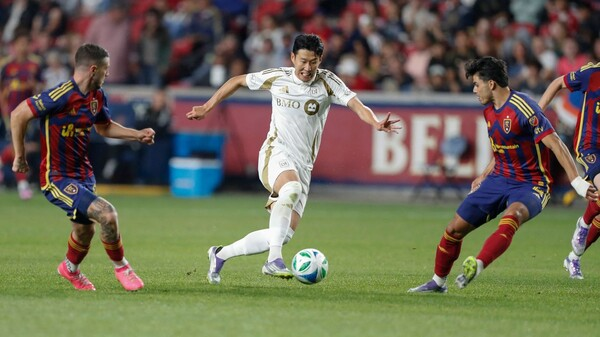

In [17]:
from IPython.display import display, HTML

display(HTML(f"""
<figure style="text-align:left">
  <img src="data:image/png;base64,{img_b64}" style="max-width:560px;height:auto;" />
</figure>
"""))